In [5]:
import os
from dotenv import load_dotenv
from sqlalchemy import create_engine
import pandas as pd

load_dotenv(override=True)

engine = create_engine(
    f"postgresql+psycopg2://{os.environ['DB_USER']}:{os.environ['DB_PASSWORD']}"
    f"@{os.environ['DB_HOST']}:{os.environ['DB_PORT']}/{os.environ['DB_NAME']}"
)

# sanity check

pd.read_sql("SELECT 1 AS ok", engine)

,ok
0,1


In [6]:
fin = pd.read_sql("SELECT * FROM financials_quarterly ORDER BY ticker, quarter", engine)

print(fin.shape)                        # expect (215, 6)
print(fin.dtypes)                       # what type is `quarter`? date or string?
display(fin.head(8))                    # eyeball real rows
display(fin[["revenue", "rd_spend", "net_income", "operating_margin"]].describe())

(215, 6)
ticker                  str
quarter              object
revenue             float64
rd_spend            float64
net_income          float64
operating_margin    float64
dtype: object


,ticker,quarter,revenue,rd_spend,net_income,operating_margin
0,AMD,2021-09-25,4.313000e+09,7.650000e+08,923000000.0,0.219801
1,AMD,2021-12-25,4.826000e+09,8.110000e+08,974000000.0,0.250104
2,AMD,2022-03-26,5.887000e+09,1.060000e+09,786000000.0,0.161542
3,AMD,2022-06-25,6.550000e+09,1.300000e+09,447000000.0,0.080305
4,AMD,2022-09-24,5.565000e+09,1.279000e+09,66000000.0,-0.011500
5,AMD,2022-12-31,5.599000e+09,1.366000e+09,21000000.0,-0.026612
6,AMD,2023-04-01,5.353000e+09,1.411000e+09,-139000000.0,-0.027088
7,AMD,2023-07-01,5.359000e+09,1.443000e+09,27000000.0,-0.003732


,revenue,rd_spend,net_income,operating_margin
count,2.130000e+02,2.080000e+02,2.130000e+02,213.000000
mean,2.975106e+10,2.840626e+09,1.200822e+10,0.213356
std,1.416601e+11,9.215198e+09,6.292645e+10,0.220217
min,4.250770e+08,1.014890e+08,-1.663900e+10,-0.681798
25%,1.247766e+09,4.207392e+08,1.195580e+08,0.106174
50%,5.824000e+09,9.340000e+08,3.320000e+08,0.234641
75%,1.127100e+10,2.239750e+09,2.472000e+09,0.326997
max,1.046090e+12,6.485774e+10,4.854654e+11,0.803695


In [7]:
fin["quarter"] = pd.to_datetime(fin["quarter"])
fin["rd_intensity"] = fin["rd_spend"] / fin["revenue"]

HIRING_TICKERS = ["AMD","AVGO","CDNS","INTC","MRVL","MU","NVDA","QCOM","TXN"]
core = fin[fin["ticker"].isin(HIRING_TICKERS)].copy()

# latest available quarter per ticker (fiscal ends differ by ~2 months — fine for a ratio)
latest = (core.sort_values("quarter")
              .groupby("ticker").tail(1)
              .sort_values("rd_intensity", ascending=False))

display(latest[["ticker","quarter","revenue","rd_spend","rd_intensity","operating_margin"]])

,ticker,quarter,revenue,rd_spend,rd_intensity,operating_margin
72,CDNS,2026-03-31,1.474220e+09,5.084370e+08,0.344885,0.292581
111,MRVL,2026-05-02,2.417800e+09,6.523000e+08,0.269791,0.140376
91,INTC,2026-03-28,1.357700e+10,3.375000e+09,0.248582,-0.230979
18,AMD,2026-03-28,1.025300e+10,2.397000e+09,0.233785,0.143958
168,QCOM,2026-03-29,1.059900e+10,2.463000e+09,0.232380,0.217851
53,AVGO,2026-05-03,2.218700e+10,2.995000e+09,0.134989,0.486231
214,TXN,2026-03-29,1.282494e+09,1.355610e+08,0.105701,0.368814
150,NVDA,2026-04-26,8.161500e+10,6.321000e+09,0.077449,0.655958
130,MU,2026-05-28,4.145600e+10,1.316000e+09,0.031745,0.803695


Intensity Bar + Revenue-vs-RND scatter

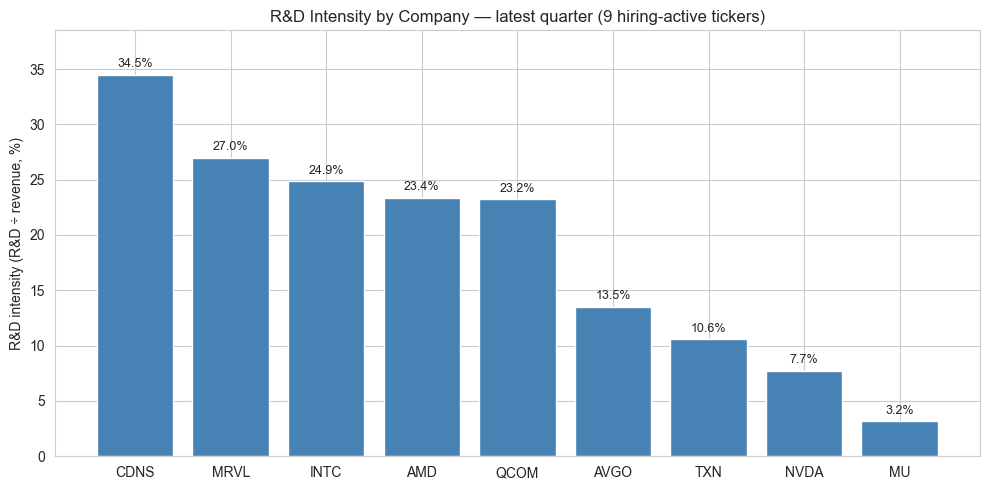

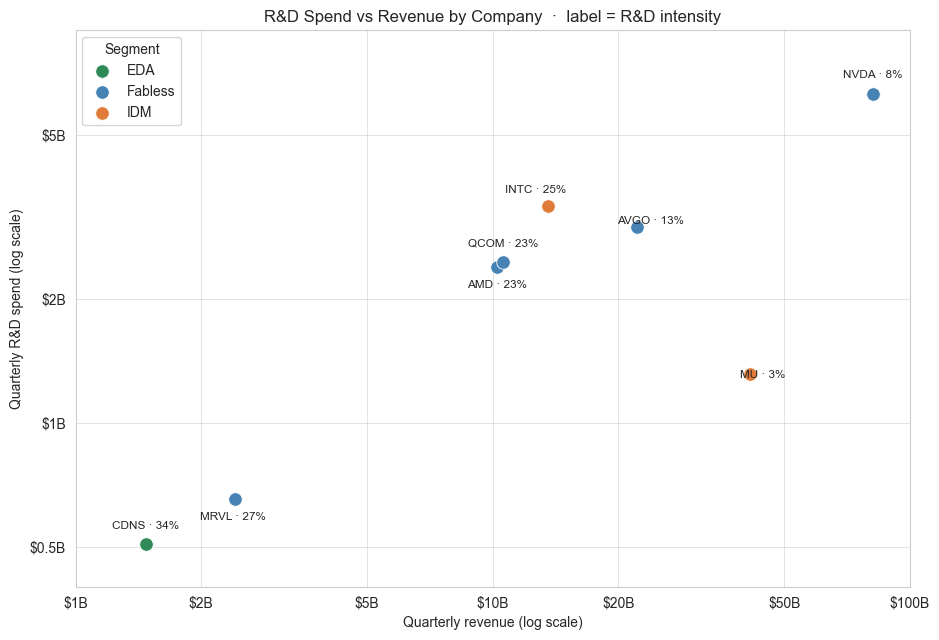

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FixedLocator, FuncFormatter
sns.set_style("whitegrid")

# --- shared setup  ---
seg = {"NVDA":"Fabless","AMD":"Fabless","QCOM":"Fabless","AVGO":"Fabless","MRVL":"Fabless",
       "INTC":"IDM","MU":"IDM","TXN":"IDM","CDNS":"EDA"}
colors = {"Fabless":"steelblue","IDM":"#e07b39","EDA":"seagreen"}
latest["segment"] = latest["ticker"].map(seg)
offsets = {"NVDA":(0,11),"MU":(9,-3),"AVGO":(10,2),"INTC":(-9,9),"QCOM":(0,11),
           "AMD":(0,-15),"TXN":(9,4),"MRVL":(-2,-15),"CDNS":(0,11)}


# --- Chart A: R&D intensity, ranked (accessible headline) ---
fig, ax = plt.subplots(figsize=(10, 5))
vals = latest["rd_intensity"] * 100
ax.bar(latest["ticker"], vals, color="steelblue")

for i, v in enumerate(vals):
    ax.text(i, v + 0.4, f"{v:.1f}%", ha="center", va="bottom", fontsize=9)

ax.set_ylabel("R&D intensity (R&D ÷ revenue, %)")
ax.set_title("R&D Intensity by Company — latest quarter (9 hiring-active tickers)")
ax.set_ylim(0, vals.max() + 4)

plt.tight_layout()
plt.savefig("rd_intensity_by_ticker.png", dpi=150, bbox_inches="tight")
plt.show()


# --- Chart B: revenue vs R&D spend, log-log, colored by segment ---
fig, ax = plt.subplots(figsize=(9.5, 6.5))
for s, sub in latest.groupby("segment"):
    ax.scatter(
               sub["revenue"]/1e9, 
               sub["rd_spend"]/1e9, 
               s=95, 
               color=colors[s],
               label=s, 
               edgecolor="white", 
               linewidth=0.6, zorder=3)
for _, r in latest.iterrows():
    dx, dy = offsets[r["ticker"]]
    ax.annotate(f'{r["ticker"]} · {r["rd_intensity"]*100:.0f}%',
                (r["revenue"]/1e9, r["rd_spend"]/1e9),
                xytext=(dx, dy), textcoords="offset points", fontsize=8.5, ha="center")

ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlim(1, 100); ax.set_ylim(0.4, 9)

ax.xaxis.set_major_locator(FixedLocator([1,2,5,10,20,50,100]))
ax.yaxis.set_major_locator(FixedLocator([0.5,1,2,5]))

ax.xaxis.set_major_formatter(FuncFormatter(lambda v,_: f"${v:g}B"))
ax.yaxis.set_major_formatter(FuncFormatter(lambda v,_: f"${v:g}B"))
ax.minorticks_off()
ax.grid(True, which="major", linewidth=0.5, alpha=0.8)

ax.set_xlabel("Quarterly revenue (log scale)")
ax.set_ylabel("Quarterly R&D spend (log scale)")
ax.set_title("R&D Spend vs Revenue by Company  ·  label = R&D intensity")
ax.legend(title="Segment", frameon=True, loc="upper left")
plt.tight_layout()
plt.savefig("rd_vs_revenue.png", dpi=150, bbox_inches="tight")
plt.show()

Observations

1) - Looking at chart A, CDNS is the highest by a considerable margin in terms of RND spending in relation to their total revenue at 34.5% with the next highest being INTC at 24.9% which is almost a 10% difference. The lowest is MU at 5.2%.
    - Given that CDNS is an EDA company that creates software to be able to produce the chips, being able to research and improve these EDA technologies is a major aspect of their success as a company especially given that their being competitor SNPS is almost neck to neck with them in terms of positioning within the EDA industry
    - MU being the lowest in terms of RND spending in relation to their revenue makes a lot of sense given that they did report the one of the highest most recent quarterly revenue and they are an IDM company with a big emphasis on also the manufacturing of storage chips rather being focusing solely on researching ways to improve the storage chips. 
        - INTC is the slight exception as they have an R&D intensity percentage comparable to other fabless companies in relation to their revenue which makes sense given they are a large player within the design and manufacturing of CPU's
    
- One major thing to note here is that the percentage of R&D spend intensity should not be taken solely as whether one company spends more on R&D than another because MU only spends 5% of their revenue but yet, through a more holistic view, spends more dollars on R&D than CDNS who spends 34% of their revenue on R&D. This serves to set a baseline for considering the size of the company in relation to their financials when doing analyses.

2) - Project was built on finding how AI has affected the semiconductor industry but a quick note is that financials alone do not bring any defensible statements from such.


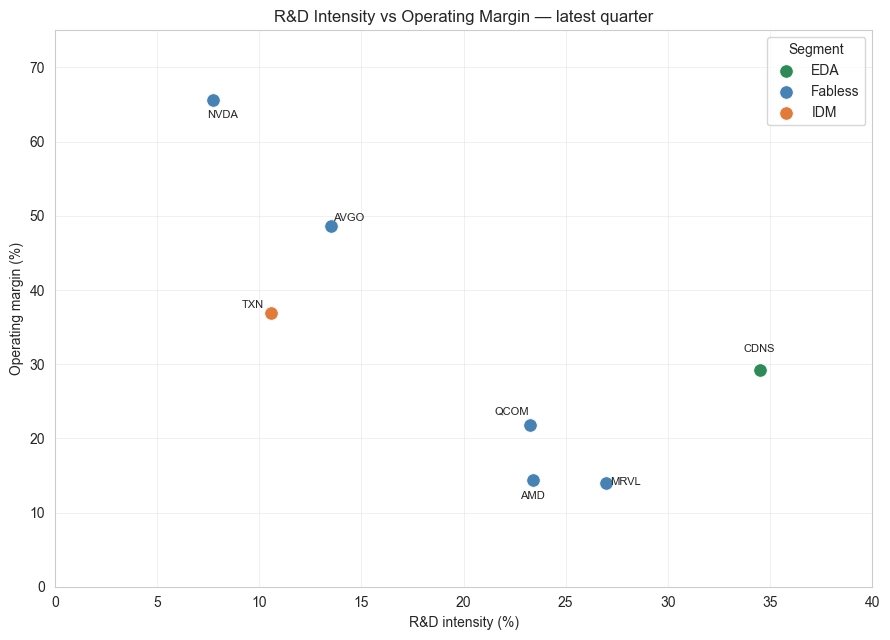

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

seg = {"NVDA":"Fabless","AMD":"Fabless","QCOM":"Fabless","AVGO":"Fabless","MRVL":"Fabless",
       "INTC":"IDM","MU":"IDM","TXN":"IDM","CDNS":"EDA"}
colors = {"Fabless":"steelblue","IDM":"#e07b39","EDA":"seagreen"}
latest["segment"] = latest["ticker"].map(seg)

# labels pushed further out to clear the markers
offsets = {"MU":(0,13),"NVDA":(7,-13),"AVGO":(13,4),"TXN":(-13,4),"CDNS":(0,13),
           "QCOM":(-13,8),"MRVL":(14,-2),"AMD":(0,-14),"INTC":(14,-3)}

fig, ax = plt.subplots(figsize=(9, 6.5))
for s, sub in latest.groupby("segment"):
    ax.scatter(sub["rd_intensity"]*100, sub["operating_margin"]*100, s=95,
               color=colors[s], label=s, edgecolor="white", linewidth=0.6, zorder=3)
for _, r in latest.iterrows():
    dx, dy = offsets[r["ticker"]]
    ax.annotate(r["ticker"], (r["rd_intensity"]*100, r["operating_margin"]*100),
                xytext=(dx, dy), textcoords="offset points", fontsize=8, ha="center")

ax.set_xlim(0, 40); ax.set_ylim(0, 75)
ax.grid(True, linewidth=0.5, alpha=0.4)   # softened so it's not busy
ax.set_xlabel("R&D intensity (%)")
ax.set_ylabel("Operating margin (%)")
ax.set_title("R&D Intensity vs Operating Margin — latest quarter")
ax.legend(title="Segment", frameon=True, loc="upper right")
plt.tight_layout()
plt.savefig("intensity_vs_margin.png", dpi=150, bbox_inches="tight")
plt.show()

In [10]:
print(latest[["rd_intensity","operating_margin"]].corr(method="spearman").iloc[0,1].round(2))


-0.8


3) - Putting R&D intensity and Operating Margin on a scatterplot, we see an inverse relationship with a considerable strength which enables us to make a assumption of correlation within higher operating margins leading to lower R&D intensity. 
        - -0.8 spearman correlation confirms the inverse relationship.

    - HOWEVER, CORRELATION DOES NOT MEAN CAUSATION

In [13]:
import pandas as pd

fin = pd.read_sql("SELECT * FROM financials_quarterly ORDER BY ticker, quarter", engine)
fin["quarter"] = pd.to_datetime(fin["quarter"])
fin["rd_intensity"] = fin["rd_spend"] / fin["revenue"]

HIRING_TICKERS = ["AMD","AVGO","CDNS","INTC","MRVL","MU","NVDA","QCOM","TXN"]
core = fin[fin["ticker"].isin(HIRING_TICKERS)].copy()

tmp = core.sort_values(["ticker","quarter"]).copy()
tmp["gap"] = tmp.groupby("ticker")["quarter"].diff().dt.days
flags = tmp[(tmp["gap"].notna()) & ((tmp["gap"] < 80) | (tmp["gap"] > 120))]

print("Quarters per ticker:")
print(core.groupby("ticker").size().to_string())
print("")
print("Non-standard gaps (expect NONE):")
if len(flags):
    print(flags[["ticker","quarter","gap"]].to_string(index=False))
else:
    print("  none - clean quarterly series")

Quarters per ticker:
ticker
AMD     19
AVGO    20
CDNS    19
INTC    19
MRVL    20
MU      19
NVDA    20
QCOM    18
TXN     19

Non-standard gaps (expect NONE):
  none - clean quarterly series


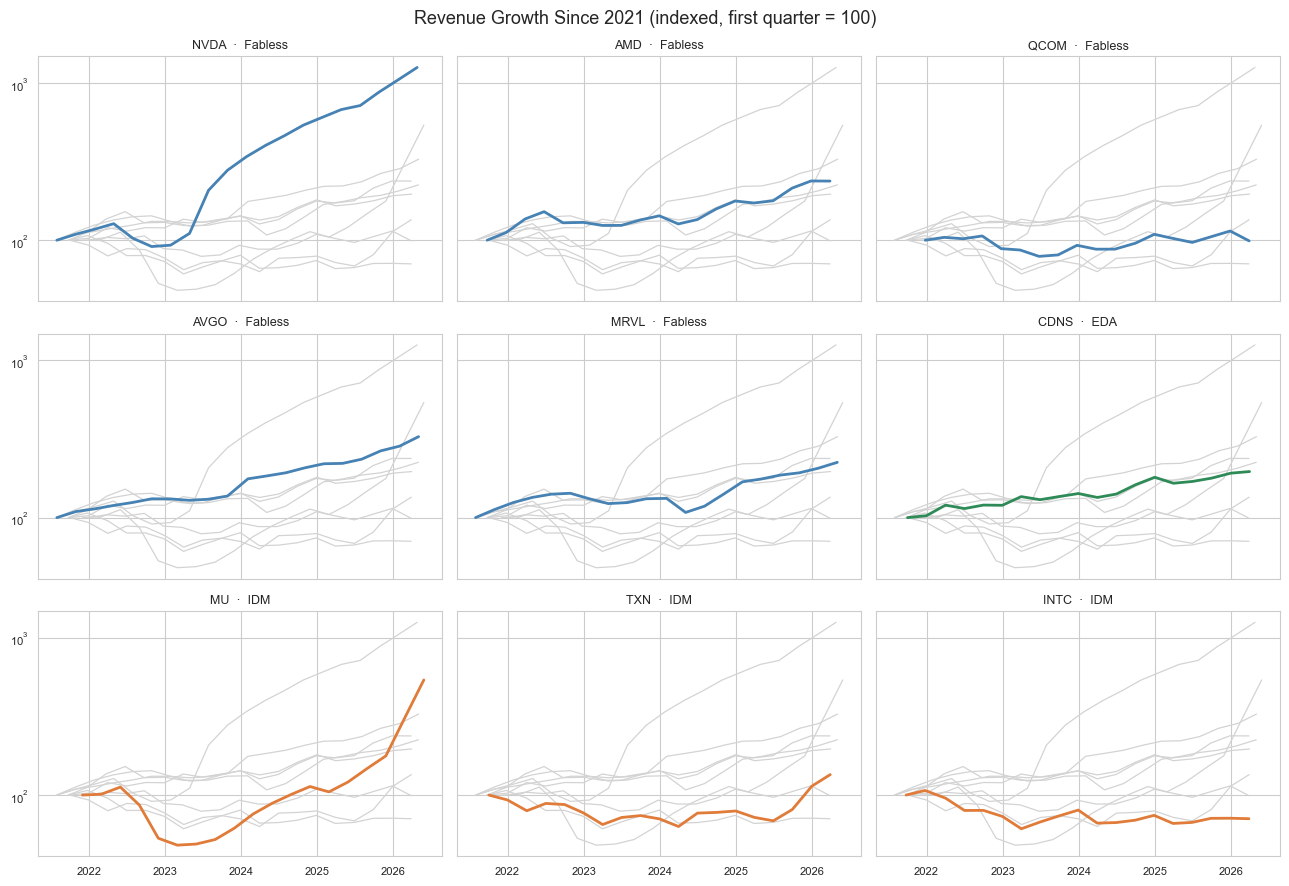

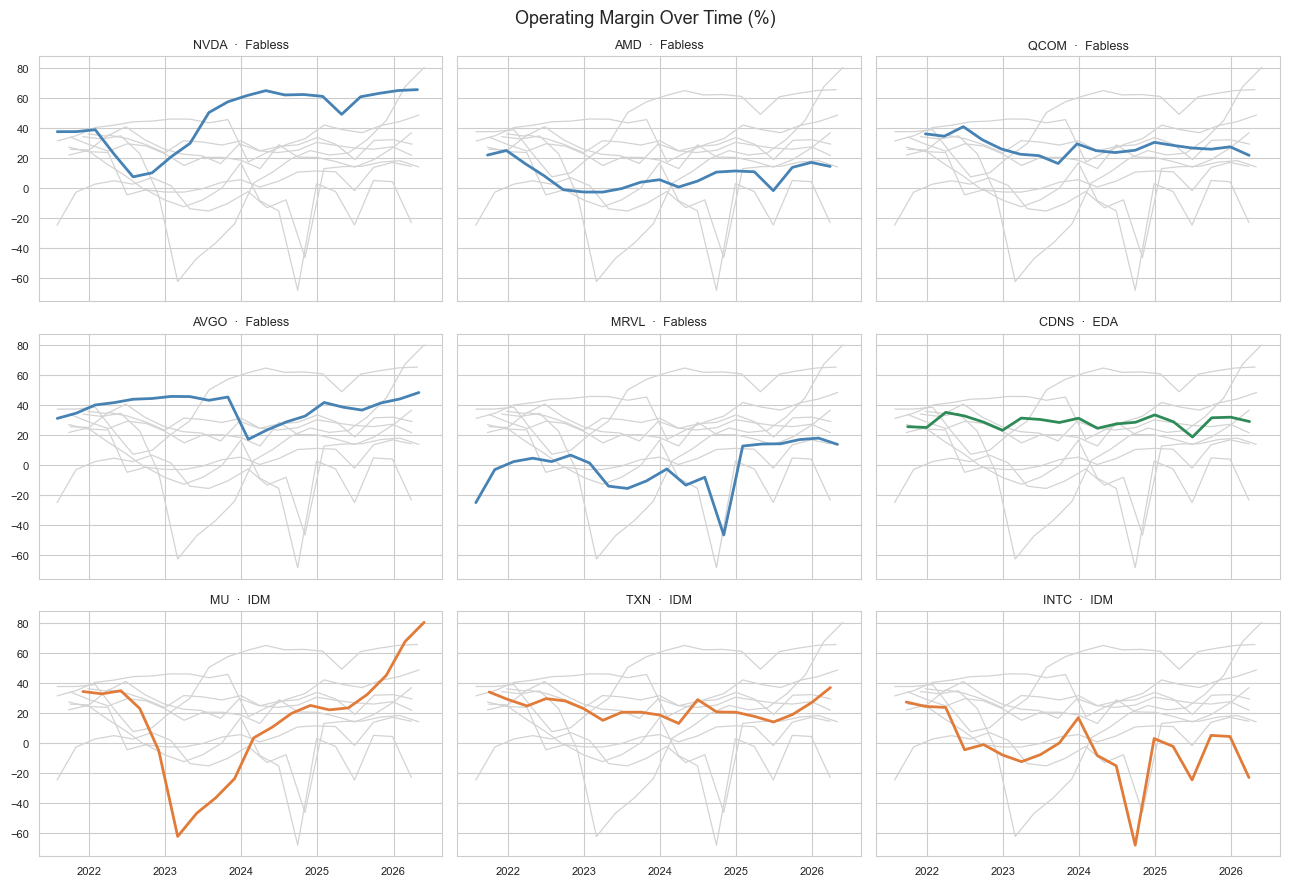

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

order = ["NVDA","AMD","QCOM","AVGO","MRVL","CDNS","MU","TXN","INTC"]
seg = {"NVDA":"Fabless","AMD":"Fabless","QCOM":"Fabless","AVGO":"Fabless","MRVL":"Fabless",
       "INTC":"IDM","MU":"IDM","TXN":"IDM","CDNS":"EDA"}
colors = {"Fabless":"steelblue","IDM":"#e07b39","EDA":"seagreen"}

for metric, title, fname in [
    ("rev_idx", "Revenue Growth Since 2021 (indexed, first quarter = 100)", "revenue_trends.png"),
    ("operating_margin", "Operating Margin Over Time (%)", "margin_trends.png"),
]:
    d = core.sort_values("quarter").copy()
    d["rev_idx"] = d.groupby("ticker")["revenue"].transform(lambda s: s / s.iloc[0] * 100)
    if metric == "operating_margin":
        d[metric] = d[metric] * 100


#chart 
    fig, axes = plt.subplots(3, 3, figsize=(13,9), sharex=True, sharey=True)
    for ax, t in zip(axes.flat, order):
        for other in order:                       # grey backdrop = the other 8
            s = d[d["ticker"] == other]
            ax.plot(s["quarter"], s[metric], color="lightgrey", linewidth=0.9, zorder=1)
        s = d[d["ticker"] == t]
        ax.plot(s["quarter"], s[metric], color=colors[seg[t]], linewidth=2.0, zorder=3)
        ax.set_title(f"{t}  ·  {seg[t]}", fontsize=9)
        ax.tick_params(labelsize=8)
    if metric == "rev_idx":
        axes[0, 0].set_yscale("log")
    fig.suptitle(title, fontsize=13)
    plt.tight_layout()
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()

Trend Observation Analysis - (Revenue Growth - Operating Margins)

    - NVDA separates from the pack in revenue after a decline from 2022 to 2023 leading to a major boom 2023 and onwards. Operating margins also increase substantially around this same timeframe hinting at operational efficiency, building a revenue that increasingly surpasses their operating costs.
        - Why could this be? Is it a surgence of a certain product or AI advancements?
            - Data that has been looked into cannot exactly verify this yet


    - MU has a similar occurence as NVDA but more drastic, with a major dip in revenue and operating margins from mid 2022 up until 2023. How it stands out from NVDA is that with revenue, it took almost 2 years (2022-2024) to be able to recover from the dip before a major increase surge. In operating margin percentages, it even went into the negatives up to as low as over -60% in operating margins up until 2024 when it became positive againa and rose drastically to 80% by 2026.
        - Data does not directly support as to why this is the case but given the volatility within a 5-year span, this could be cyclic
        - This could also be a possible restructuring of their business model or a major investment but the cyclic reasoning is a more feasible hypothesis

    - Across IDM companies (MU, TXN, and INTL), their operating margins differ starkly from one-another
        - MU cyclic bust and boom
        - TXN consistently around 20-40%
        - INTC slight downward trajectory while already hovering around 0% with a major decline mid 2024 before coming back up by 2025 as to which it stayed volatile (but not as volatile as MU)
    
        - Segment label (semiconductor IDM - designs and produces chips) does not hold a categorization trend that can be expected within their respective operating margins
            - Although, what can be said is that these 3 companies differ in the products that they make which is a very plausible reasoning for these differences with MU - Memory, TXN - Analog & Embedded chips, INTL - logic/CPUs